### ライブラリの準備

###モジュールのインポート

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import datetime
#from tqdm import tqdm
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from PIL import Image
from collections import deque
from typing import Sequence, Dict, Tuple, Union

import torch
from torch import nn
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
import torchvision.datasets as dataset
from torchvision.transforms import v2
import torchvision.transforms as T

from transformers import  CLIPVisionModel, get_linear_schedule_with_warmup, AutoModelForCausalLM, AutoTokenizer, GPT2Tokenizer, GPT2Model

import util
import levenshtein
from nltk import bleu_score
#from cidereval import cider, ciderD

### CaptioningTransformer

In [2]:
class CaptioningTransformer(nn.Module):
    '''
    CaptioningTransformerのコンストラクタ
    dim_embedding  : 埋め込み次元
    dim_feedforward: FNNの中間特徴次元
    num_heads      : マルチヘッドアテンションのヘッド数
    num_layers     : Transformerデコーダ層の数
    vocab_size     : 辞書の次元
    null_index     : NULLのID
    dropout        : ドロップアウト確率
    '''
    def __init__(self, clip_dim: int, dim_embedding: int, vocab_size: int, tokenizer, dropout: float = 0.1, endoftext_token_id: int=50256):
        super().__init__()

        #CLIP
        #path = "../clip-vit-large-patch14-336"
        #self.clip_model = CLIPVisionModel.from_pretrained(pretrained_model_name_or_path = path, output_hidden_states = True)
        model_id = "openai/clip-vit-large-patch14-336"
        self.clip_model = CLIPVisionModel.from_pretrained(model_id, output_hidden_states = True)
        
        # Dense Connector
        #self.dc_ln = nn.LayerNorm( clip_dim * 3 )
        self.dc_linear = nn.Linear( clip_dim * 3, dim_embedding )
        self.dropout = nn.Dropout( dropout )        
        self.ln_memory = nn.LayerNorm( dim_embedding )

        # Down Sampling
        self.conv1 = nn.Conv1d( dim_embedding, dim_embedding, 1, 5 )
        self.conv2 = nn.Conv1d( dim_embedding, dim_embedding, 1, 2 )

        # Word Embeidding
        self.emb = nn.Embedding( vocab_size, dim_embedding )
        
        #GPT2 as decoder
        #path = "./models--gpt2-large/snapshots/32b71b12589c2f8d625668d2335a01cac3249519"
        #self.decoder = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path = path)  
        model_id = "openai-community/gpt2-large" 
        self.decoder = AutoModelForCausalLM.from_pretrained(model_id)  
    
        # Others
        self.dim_embedding = dim_embedding
        self.tokenizer = tokenizer
        self.endoftext_token_id = endoftext_token_id

    ''' CaptioningTransformerの順伝播処理
    features: 画像特徴量 [バッチサイズ, 埋め込み次元]
    captions: 正解キャプション [バッチサイズ, 系列長]
    '''
    def forward(self, images: torch.Tensor, captions: torch.Tensor ):

        self.device = images.device

        memory = self.clip_model( images )
        memory = self.dense_connector( memory )
        memory = self.dropout( memory )
        memory = self.ln_memory( memory )

        memory = self.conv1( memory.transpose(1,2) )
        memory = self.conv2( memory ).transpose( 1, 2 )

        def my_index( list0, int0):
            if int0 in list0:
                return list0.index( int0 )
            else:
                return -1
        
        pad_pos = torch.tensor( [], device = self.device, dtype=torch.int )
        for caption in captions:
            pad_pos0 = my_index( caption.tolist(), self.endoftext_token_id ) 
            if pad_pos0 == -1:
                pad_pos = torch.cat( [pad_pos, torch.tensor([len( caption ) + 1]  , device = self.device)], dim = 0 )
            else:
                pad_pos = torch.cat( [pad_pos, torch.tensor([pad_pos0 + 1], device = self.device)], dim = 0 )
            
        emb_caption = self.emb( captions )

        gpt_in = torch.cat( [memory, emb_caption], dim = 1 )
        gpt_in_padding_masks = torch.zeros( gpt_in.shape[:2], device = self.device, dtype=torch.float )
        for n in range( len( gpt_in_padding_masks ) ):
            gpt_in_padding_masks[n,:memory.size(1) + pad_pos[n]] = 1.0
        
        #outputs = self.decoder( gpt_in, gpt_in_padding_masks )
        outputs = self.decoder( inputs_embeds = gpt_in, attention_mask = gpt_in_padding_masks ).logits
        #outputs = self.decoder( inputs_embeds = gpt_in, attention_mask = gpt_in_padding_masks ).last_hidden_state
        #print( "ouputs:", outputs )
        outputs = outputs[:,memory.size(1) - 1:]
        
        return outputs

    def dense_connector(self, memory ):
        tmp1 = torch.tensor([], device = self.device )
        tmp2 = torch.tensor([], device = self.device )
        tmp_full = len( memory.hidden_states )
        tmp_half = tmp_full // 2
        for i in range( 0, tmp_half ):
            tmp1 = torch.cat( [tmp1, memory.hidden_states[i][None]], dim = 0 )
        tmp1 = torch.sum(tmp1, dim=0) / tmp_half
        for i in range( tmp_half, tmp_full ):
            tmp2 = torch.cat( [tmp2, memory.hidden_states[i][None]], dim = 0 )
        tmp2 = torch.sum(tmp2, dim=0 ) / ( tmp_full - tmp_half )
        tmp3 = torch.cat([tmp1, tmp2], dim=-1)
        tmp3 = torch.cat( [ memory.last_hidden_state, tmp3], dim = -1 )
        #tmp3 = sel.dc_ln( tmp3 )
        tmp3 = self.dc_linear( tmp3 )
        return tmp3

In [3]:
class MyDataset(Dataset):
    def __init__(self, file_path: str, img_directory: str, transforms, tokenizer) -> None:
        super().__init__()
        self.img_directory = img_directory
        self.transforms = transforms
        # TODO: fix to original data
        #画像の前処理
        self.img_file = []
        self.tokenss = []
        with open( file_path, "r" ) as f:
            line = f.readline()
            i = 0
            while line:
                if i % 100000 == 0:
                #    #print( line.split("\t")[0])
                #    #print( line.split("\t")[1])
                    print( "i:", i )
                i += 1
                self.img_file.append(line.split("\t" )[0])
                caption = line.split("\t")[1].replace( "\r\n", "" ).replace( "\n", "").replace( "\r", "" ) + " <|endoftext|>"
                #print( "caption:", caption )
                id_tokens = tokenizer.encode( caption, add_special_tokens=True )
                id_tokens = torch.tensor( id_tokens, requires_grad = False  )
                #print( "id_tokens:", id_tokens )
                self.tokenss.append( id_tokens )

                line = f.readline()

    # ここで取り出すデータを指定している
    def __getitem__(
        self,
        index: int
    ):
        tokens = self.tokenss[index]
        img_file = self.img_file[index] + ".jpg"
        img_path = os.path.join( self.img_directory, img_file ) #index番目の画像のパスを取得
        img = Image.open(img_path) #PIL形式で画像を読み込み
        if img.mode != 'RGB':
            img = img.convert("RGB")
        #bw_p = img.convert('L')
        #array_p = np.asarray(bw_p)
        #fft_p = abs(np.fft.rfft2(array_p))
        #new_p = Image.fromarray(fft_p)
        #if new_p.mode != 'RGB':
        #    new_p = new_p.convert('RGB')

        # データの変形 (transforms)
        #img = self.transforms(new_p)
        img = self.transforms(img)
        #if img.dim() != 3:
        #    print( "in Mydataset size of img:", img.size() )
        
        return img, tokens

    # この method がないと DataLoader を呼び出す際にエラーを吐かれる
    def __len__(self) -> int:
        return len(self.tokenss)

In [4]:
def collate_func(batch: Sequence[Tuple[Union[torch.Tensor, str]]], pad_index ):
    imgs, tokens = zip(*batch)

    max_length = 0
    for target in tokens:
        if max_length < len( target ):
            max_length = len( target )
    
    targets = []
    lengths = []
    for target in tokens:
        pad_len = max_length - len( target ) 
        #print( "target:", target )
        input2= F.pad( target, (0, pad_len), mode='constant', value = pad_index)
        targets.append( input2 )
        lengths.append( len( target ) )
    
    imgs = torch.stack( imgs, dim = 0 )
    targets = torch.stack( targets, dim = 0 )
    lengths = torch.tensor( lengths )

    #if imgs.dim() != 4:
    #   print( "in collate imgs size:", imgs.size() )
    
    return imgs, targets, lengths

In [5]:
#path = "./models--gpt2-large/snapshots/32b71b12589c2f8d625668d2335a01cac3249519"
#tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path = path)
model_id = "openai-community/gpt2-large" 
tokenizer = AutoTokenizer.from_pretrained(model_id)
vocab_size = len( tokenizer )
endoftext_token_id = 50256

caption = "Hello World! <|endoftext|>".lower()
token_ids = tokenizer.encode( caption )
#decoded = tokenizer.decode( token_ids )
#print( decoded )
#print( tokenizer.tokenize( decoded ) )
individual_decoded_tokens = list(map(tokenizer.decode, token_ids))
print( individual_decoded_tokens )

tmp = tokenizer.decode( 91 )
print( tmp )

/home/uchiyats/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2025-08-31 06:22:52.694431: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-31 06:22:52.706160: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756588972.720604    5525 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756588972.7246

['hello', ' world', '!', ' ', '<|endoftext|>']
|


i: 0
i: 100000
i: 200000
i: 300000
i: 400000
i: 500000
torch.Size([4, 56])
torch.Size([4, 3, 336, 336])


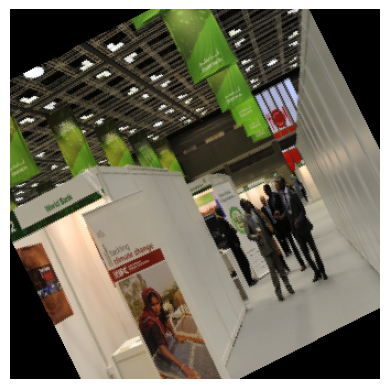

In [6]:
#path = "./models--gpt2-large/snapshots/32b71b12589c2f8d625668d2335a01cac3249519"
#tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path = path)
model_id = "openai-community/gpt2-large" 
tokenizer = AutoTokenizer.from_pretrained(model_id)
vocab_size = len( tokenizer )
endoftext_token_id = 50256
collate_func_lambda = lambda x: collate_func(x, word_to_id['<pad>'])

# 画像のtransformsを定義
transforms = v2.Compose([
    v2.Resize((336, 336)),
    #v2.ToTensor(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.AutoAugment(),
    ## Coco データセット 2017 train の平均と標準偏差
    #v2.Normalize((0.456,0.427,0.401),(0.224,0.219,0.231) )
    # Clip Model の config から引用。
    v2.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
])

# 画像のtransformsを定義
#transforms = T.Compose([
#    T.Resize((336, 336)),
#    T.RandomHorizontalFlip(),
#    T.ToTensor(),
#    # ImageNetデータセットの平均と標準偏差
#    T.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
#])


# v7 データセット
train_dataset = MyDataset( file_path="../CLIP_LLM_AR/dataset.txt",
                           img_directory = "/mnt/ssd2/v7/img",
                           #img_directory = "smb://192.168.1.2/img/v7/",
                           transforms=transforms, tokenizer = tokenizer)

# Subset samplerの生成
#val_set, train_set = util.generate_subset(
#    train_dataset, config.val_ratio)
test_set, val_set, train_set = util.generate_subset_test_val_train(
    train_dataset, 0.1, 0.1 )
    
# 学習時にランダムにサンプルするためのサンプラー
train_sampler = SubsetRandomSampler(train_set)

# DataLoaderを生成
collate_func_lambda = lambda x: collate_func(x, endoftext_token_id )
train_loader = torch.utils.data.DataLoader(
                    train_dataset,
                    batch_size=4,
                    num_workers=0,
                    shuffle = False,
                    #sampler=train_sampler,
                    pin_memory = True,
                    collate_fn=collate_func_lambda)
transforms_inv = v2.Compose([
    v2.Normalize((-0.48145466/0.26862954, -0.4578275/0.26130258, -0.40821073/0.27577711), (1/0.26862954,1/0.26130258,1/0.27577711)),
    v2.ToPILImage()
])


#for n, (imgs, targets, lengths) in enumerate( train_loader ):
#    #print( "imgs size:", imgs.size())
#    if n % 100 == 0:
#        print( "n:", n )
    
imgs, targets, lengths = next(iter(train_loader))

##print( targets )
print( targets.size() )
print( imgs.size() )
##print( imgs[0] )
##img[0].show()
inv_img = transforms_inv( imgs[0] )
plt.imshow( inv_img )
plt.axis('off')
plt.show()

###学習におけるハイパーパラメータやオプションの設定

In [5]:
class ConfigTrain(object):
    '''
    ハイパーパラメータ、システム共通変数の設定
    '''
    def __init__(self):

        # ハイパーパラメータ
        self.clip_dim = 1024
        self.dim_embedding = 1280   # 埋め込み層の次元
        #self.lr = 5e-5            # 学習率
        #self.lr = 2e-5            # 学習率
        #self.lr = 1e-5            # 学習率
        #self.lr = 2e-6            # 学習率
        #self.lr = 1e-6            # 学習率
        #self.lr = 5e-7            # 学習率
        self.lr = 2e-7            # 学習率
        self.dropout = 0.1
        #self.batch_size = 128       # ミニバッチ数
        self.batch_size = 8       # ミニバッチ数
        #self.batch_size = 4       # ミニバッチ数
        #self.batch_size = 2       # ミニバッチ数
        #self.num_epochs = 100       # エポック数→Colab無料版でテストする際は10未満に修正を推奨
        #self.num_epochs = 60       # エポック数→Colab無料版でテストする際は10未満に修正を推奨
        self.num_epochs = 5       # エポック数→Colab無料版でテストする際は10未満に修正を推奨
        self.use_amp = True
        #self.use_amp = False
        #self.use_saved_pth = True
        self.use_saved_pth = False
        self.vocab_size = 50257
        self.endoftext_token_id = 50256

        # パスの設定
        self.img_directory = '/mnt/ssd2/v7/img'
        self.anno_file = '../CLIP_LLM_AR/dataset.txt'
        self.save_directory = './model'

        # 検証に使う学習セット内のデータの割合
        self.test_ratio = 0.1
        self.val_ratio = 0.1
        #self.val_ratio = 0.0004
        #self.test_ratio = 0.0004
        
        # 学習に使うデバイス
        #self.device = 'cuda'
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        #self.device = 'cpu'
        
        # データローダーに使うCPUプロセスの数
        #self.num_workers = 4
        self.num_workers = 0 if self.device == torch.device('cpu') else 8
        #self.num_workers = 0
        
        # 移動平均で計算する損失の値の数
        self.moving_avg = 100

In [8]:
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
#path = "./models--gpt2-large/snapshots/32b71b12589c2f8d625668d2335a01cac3249519"
#tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path = path)
model_id = "openai-community/gpt2-large" 
tokenizer = AutoTokenizer.from_pretrained(model_id)
vocab_size = len( tokenizer )
endoftext_token_id = 50256
model = CaptioningTransformer(clip_dim = 1024, dim_embedding=1280, vocab_size=vocab_size,tokenizer=tokenizer, \
                             dropout = 0.1, endoftext_token_id = endoftext_token_id ).to(device)
images = torch.randn( ( 2, 3, 336,336 ), device = device )
captions = torch.randint( 0, vocab_size, size=( 2, 50  ), device = device )
outputs = model( images, captions[:,:-1] )

print( outputs.size() )

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

torch.Size([2, 50, 50257])


### 学習を行う

In [6]:
config = ConfigTrain()

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print( "use_amp:", config.use_amp )

#path = "./models--gpt2-large/snapshots/32b71b12589c2f8d625668d2335a01cac3249519"
#tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path = path)
model_id = "openai-community/gpt2-large" 
tokenizer = AutoTokenizer.from_pretrained(model_id)
vocab_size = len( tokenizer )
endoftext_token_id = 50256

# モデル出力用のディレクトリを作成
os.makedirs(config.save_directory, exist_ok=True)

# 画像のtransformsを定義
transforms = v2.Compose([
    v2.Resize((336, 336)),
    #v2.ToTensor(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.AutoAugment(),
    ## Coco データセット 2017 train の平均と標準偏差
    #v2.Normalize((0.456,0.427,0.401),(0.224,0.219,0.231) )
    # Clip Model の config から引用。
    v2.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
])

# v7 データセット
train_dataset = MyDataset( file_path=config.anno_file,
                           img_directory = config.img_directory,
                           transforms=transforms,tokenizer=tokenizer)

# Subset samplerの生成
test_set, val_set, train_set = util.generate_subset_test_val_train(
    train_dataset, config.test_ratio, config.val_ratio )
    
# 学習時にランダムにサンプルするためのサンプラー
train_sampler = SubsetRandomSampler(train_set)

# DataLoaderを生成
collate_func_lambda = lambda x: collate_func(x, endoftext_token_id)
train_loader = torch.utils.data.DataLoader(
                    train_dataset,
                    batch_size=config.batch_size,
                    num_workers=config.num_workers,
                    sampler=train_sampler,
                    collate_fn=collate_func_lambda)

val_loader = torch.utils.data.DataLoader(
                    train_dataset,
                    batch_size=config.batch_size,
                    num_workers=config.num_workers,
                    sampler=val_set,
                    collate_fn=collate_func_lambda)

test_loader = torch.utils.data.DataLoader(
                    train_dataset,
                    #batch_size=config.batch_size,
                    batch_size=1,
                    num_workers=config.num_workers,
                    sampler=test_set,
                    collate_fn=collate_func_lambda)


print( "device:", config.device )
print( "学習セット数:",len( train_loader ) )
print( "評価セット数:",len( val_loader ))
print( "テストセット数:",len( test_loader ))
    
# モデルの定義
model = CaptioningTransformer( config.clip_dim, config.dim_embedding, config.vocab_size, tokenizer,\
                              config.dropout, config.endoftext_token_id )
model = model.to(config.device) 

# 損失関数の定義
criterion = nn.CrossEntropyLoss( reduction = 'mean' )

# 最適化手法の定義
optimizer = torch.optim.AdamW( model.parameters() , lr=config.lr)

# 全ステップ数
num_global_steps = len( train_loader ) * config.num_epochs
print( "num_global_steps:", num_global_steps )
num_warmup_steps = num_global_steps * 0.1
print( "num_warmup_steps:", num_warmup_steps )
#スケジューラーの定義
scheduler = get_linear_schedule_with_warmup( optimizer, num_warmup_steps, num_global_steps )    

PATH = f'{config.save_directory}/model_ar_hfgpt2_v7_curr.pth'
print( "use_saved_pth:", config.use_saved_pth )
print( "exist saved_pth:", os.path.isfile(PATH) ) 
if config.use_saved_pth and os.path.isfile(PATH):
    checkpoint = torch.load(PATH)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    ##device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    ## optimizerのstateを現在のdeviceに移す。これをしないと、保存前後でdeviceの不整合が起こる可能性がある。
    #for state in optimizer.state.values():
        #for k, v in state.items():
            #if isinstance(v, torch.Tensor):
                #state[k] = v.to(device)
    begin_epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    global_step = checkpoint['global_step']
else:
    begin_epoch = 0
    global_step = 0

print( "begin_epoch:", begin_epoch )
print( "global_step:", global_step )
    
len_tr_loader = len( train_loader )
train_param = len_tr_loader // 3
len_val_loader = len( val_loader )
#train_param = len_val_loader // 3
val_param = len_val_loader // 3
print( "train_param:", train_param )
print( "val_param:", val_param )

# 学習経過の書き込み
now = datetime.datetime.now()
train_loss_file = '{}/MyOriginal_train_loss_{}.csv'\
    .format(config.save_directory, now.strftime('%Y%m%d_%H%M%S'))
with open(train_loss_file, 'a') as f:
    print(f'{len_tr_loader}', file=f) 
val_loss_file = '{}/MyOriginal_val_loss_{}.csv'\
    .format(config.save_directory, now.strftime('%Y%m%d_%H%M%S'))
with open(val_loss_file, 'a') as f:
    print(f'{len_val_loader}', file=f) 
norm_file = '{}/norm_{}.csv'\
    .format(config.save_directory, now.strftime('%Y%m%d_%H%M%S'))

# 学習
val_loss_best = float('inf')

fn = bleu_score.SmoothingFunction().method7

# AMP用のスケーラー
scaler = GradScaler(enabled=config.use_amp)

for epoch in range(begin_epoch, config.num_epochs):
    with tqdm(train_loader) as pbar:
    #with tqdm(val_loader) as pbar:
        pbar.set_description(f'[エポック {epoch + 1}]')

        # 学習モードに設定
        model.train()

        train_losses = deque()
        train_errors = deque()
        train_bleus = deque()
        #train_ciders = deque()
        for n_batch, (imgs, captions, caption_lengths) in enumerate( pbar ):
            # ミニバッチを設定
            imgs = imgs.to(config.device)
            captions = captions.to(config.device)
            #caption_lengths = torch.tensor(caption_lengths).to(config.device)
                
            optimizer.zero_grad()

            with autocast(str(config.device),enabled=config.use_amp):
                outputs = model( imgs, captions[:,:-1] )
                # 損失の計算
                loss = criterion(outputs.transpose(1,2), captions)

            hypo_ids = torch.argmax( outputs, dim = 2 )
                
            # 誤差逆伝播
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            clip_grad_threshold = 5.0
            torch.nn.utils.clip_grad_norm_(\
                    model.parameters(),
                    clip_grad_threshold)
            # オプティマイザにより，パラメータを更新する
            scaler.step(optimizer)
            scaler.update()            
            
            scheduler.step()

            #for name, param in model.named_parameters():
            #    print( name )
            # 勾配消失が起こっていないか監視
            norm0 = torch.sqrt( torch.norm( model.clip_model.vision_model.encoder.layers[0].self_attn.q_proj.weight.grad, p = 2 ) ).item()
            norm1 = torch.sqrt( torch.norm( model.decoder.transformer.h[35].attn.c_attn.weight.grad, p = 2 ) ).item()
            norm_mean = torch.mean( torch.stack ([ torch.sqrt( torch.norm( param.grad, p = 2 ) ) \
                                                  for param in model.parameters() if param.grad is not None ] ) ).item()
            with open(norm_file, 'a') as f:
                print( "epcoch:", epoch, ", step:", global_step, ", norm0:", norm0, ", norm1:", norm1, ", norm_mean:", norm_mean, file=f  )
                f.flush()
            global_step += 1

            n = 0
            hypo_sentence = []
            ref_sentence = []
            hypo_sentence1 = []
            ref_sentence1 = []
            total_error = 0
            total_token_length = 0
            total_bleu = 0
            #total_cider = 0
            n2 = 0
            for n3, (hypo_id, caption) in enumerate( zip( hypo_ids, captions )):
                #print( "n_batch:", n_batch, " n3:", n3, "caption:", caption )
                hypo = tokenizer.decode( [token_id for token_id in hypo_id.tolist() if token_id != 50256 ] )
                reference = tokenizer.decode( [token_id for token_id in caption.tolist() if token_id != 50256 ] )
                hypo_tokens = list(map(tokenizer.decode, hypo_id.tolist()))
                ref_tokens = list(map(tokenizer.decode, caption.tolist() ))
                hypo_tokens = [ token for token in hypo_tokens if token != "<|endoftext|>"]
                ref_tokens = [ token for token in ref_tokens if token != "<|endoftext|>"]
                #print( "hypo_tokens:", hypo_tokens )
                #print( "ref_tokens:", ref_tokens )
                
                # 認識誤りを計算
                (error, substitute, delete, insert, ref_length) = levenshtein.calculate_error(hypo_tokens,ref_tokens)
                # 誤り文字数を累積する
                total_error += error
                # 文字の総数を累積する
                total_token_length += ref_length

                bleu = bleu_score.sentence_bleu( [reference], hypo, smoothing_function=fn  )
                #cider_ = cider(predictions=[hypo], references=[[reference]])['avg_score']
        
                total_bleu += bleu
                #total_cider += cider_
                
                if n < 1 and n_batch == len( train_loader ) - 1 :
                #if n < 1 and n_batch == len( val_loader ) - 1 :
                    hypo_sentence.append( hypo )
                    ref_sentence.append( reference )
                if n < 1 and n_batch % train_param == 0:
                    hypo_sentence1.append( hypo )
                    ref_sentence1.append( reference )
                    
                n += 1
                n2 += 1
            
            avg_error = total_error / total_token_length * 100
            avg_bleu = total_bleu / n2 * 100
            #avg_cider = total_cider / n2
            
            # 学習時の損失をログに書き込み
            train_losses.append(loss.item())
            train_errors.append( avg_error )
            train_bleus.append( avg_bleu )
            #train_ciders.append( avg_cider )
            if len(train_losses) > config.moving_avg:
                train_losses.popleft()
                train_errors.popleft()
                train_bleus.popleft()
                #train_ciders.popleft()
            mean_loss = torch.Tensor(train_losses).mean().item()
            mean_error = torch.Tensor(train_errors).mean().item()
            mean_bleu = torch.Tensor(train_bleus).mean().item()
            pbar.set_postfix({
                'loss': mean_loss,
                'WER': mean_error,
                'BLEU': mean_bleu,
                #'CIDER': torch.Tensor(train_ciders).mean().item()
            })
            with open(train_loss_file, 'a') as f:
                #print(f'{epoch}, {loss.item()},  {avg_error}, {avg_bleu}, {avg_cider}', file=f)
                print(f'{epoch}, {mean_loss}, {mean_error}, {mean_bleu}', file=f)
            print_flag = 1
            for ( hypo_se, ref_se ) in zip( hypo_sentence1, ref_sentence1 ):
                if print_flag == 1:
                    print( "lr:", optimizer.param_groups[0]["lr"] )
                    print_flag = 0
                #print(f'Train epoch = {epoch}, loss = {loss.item()}, WER = {avg_error}, BLEU = {avg_bleu}, CIDER = {avg_cider}')
                print(f'Train epoch = {epoch}, loss = {mean_loss}, WER = {mean_error}, BLEU = {mean_bleu}')
                print( "refe:", ref_se )
                print( "hypo:", hypo_se )
                    
            for ( hypo_se, ref_se ) in zip( hypo_sentence, ref_sentence ):
                print(f'Train epoch = {epoch}, loss = {mean_loss}, WER = {mean_error}, BLEU = {mean_bleu}')
                #print(f'Train epoch = {epoch}, loss = {loss.item()}, WER = {avg_error}, BLEU = {avg_bleu}, CIDER = {avg_cider}')
                print( "refe:", ref_se )
                print( "hypo:", hypo_se )

    # 学習率を表示
    print(f'学習率: {optimizer.param_groups[0]['lr']}')
    train_loss = np.mean(train_losses)
    train_error = np.mean(train_errors )
    train_bleu = np.mean(train_bleus )
    #train_cider = np.mean(train_ciders )
    print(f'Train loss: {train_loss}')
    print(f'Train WER: {train_error}')        
    print(f'Train BLEU: {train_bleu}')
    #print(f'Train CIDER: {train_cider}')

    # 検証
    with tqdm(val_loader) as pbar:
        pbar.set_description(f'[検証]')

        # 評価モード
        model.eval()

        val_losses = deque()
        val_errors = deque()
        val_bleus = deque()
        #val_ciders = deque()
        for n_batch, (imgs, captions, caption_lengths) in enumerate( pbar ):

            # ミニバッチを設定
            imgs = imgs.to(config.device)
            captions = captions.to(config.device)
            #caption_lengths = torch.tensor( caption_lengths ).to(config.device)
                
            with torch.no_grad():
                outputs = model( imgs, captions[:,:-1] )
                hypo_ids = torch.argmax( outputs, dim = 2 )

                # 損失の計算
                loss = criterion( outputs.transpose(1,2), captions )
                
            val_losses.append(loss.item())

            n = 0
            hypo_sentence = []
            ref_sentence = []
            hypo_sentence1 = []
            ref_sentence1 = []
            total_error = 0
            total_token_length = 0
            total_bleu = 0
            #total_cider = 0
            n2 = 0
            for (hypo_id, caption) in zip( hypo_ids, captions ):
                hypo = tokenizer.decode( [token_id for token_id in hypo_id.tolist() if token_id != 50256 ] )
                reference = tokenizer.decode( [token_id for token_id in caption.tolist() if token_id != 50256 ] )
                hypo_tokens = list(map(tokenizer.decode, hypo_id.tolist()))
                ref_tokens = list(map(tokenizer.decode, caption.tolist() ))
                hypo_tokens = [ token for token in hypo_tokens if token != "<|endoftext|>"]
                ref_tokens = [ token for token in ref_tokens if token != "<|endoftext|>"]
                        
                # 認識誤りを計算
                (error, substitute, delete, insert, ref_length) = levenshtein.calculate_error(hypo_tokens, ref_tokens)
                    
                # 誤り文字数を累積する
                total_error += error
                # 文字の総数を累積する
                total_token_length += ref_length

                bleu = bleu_score.sentence_bleu( [reference], hypo, smoothing_function=fn  )
                #cider_ = cider(predictions=[hypo], references=[[reference]])['avg_score']
        
                total_bleu += bleu
                #total_cider += cider_
                #print("hypo:", ' '.join(hypo))

                if n < 1 and n_batch == len( val_loader ) - 1:
                    hypo_sentence.append( hypo )
                    ref_sentence.append( reference )
                        
                if n < 1 and n_batch % val_param == 0:
                    hypo_sentence1.append( hypo )
                    ref_sentence1.append( reference )
                    
                n += 1
                n2 += 1
                
            avg_error = total_error / total_token_length * 100                    
            avg_bleu = total_bleu / n2 * 100
            #avg_cider = total_cider / n2

            # 学習時の損失をログに書き込み
            val_losses.append(loss.item())
            val_errors.append( avg_error )
            val_bleus.append( avg_bleu )
            if len(val_losses) > config.moving_avg:
                val_losses.popleft()
                val_errors.popleft()
                val_bleus.popleft()
            mean_loss = torch.Tensor(val_losses).mean().item()
            mean_error = torch.Tensor(val_errors).mean().item()
            mean_bleu = torch.Tensor(val_bleus).mean().item()
            pbar.set_postfix({
                'loss': mean_loss,
                'WER': mean_error,
                'BLEU': mean_bleu,
            })
            # Validation Lossをログに書き込み
            with open(val_loss_file, 'a') as f:
                print(f'{epoch}, {mean_loss},  {mean_error}, {mean_bleu}', file=f)

            for ( hypo_se, ref_se ) in zip( hypo_sentence1, ref_sentence1 ):
                print(f'Val epoch = {epoch}, loss = {mean_loss}, WER = {mean_error}, BLEU = {mean_bleu}')
                print( "refe:", ref_se )
                print( "hypo:", hypo_se )
                    
            for ( hypo_se, ref_se ) in zip( hypo_sentence, ref_sentence ):
                print(f'Val epoch = {epoch}, loss = {mean_loss}, WER = {mean_error}, BLEU = {mean_bleu}')
                print( "refe:", ref_se )
                print( "hypo:", hypo_se )

    # Loss 表示
    val_loss = np.mean(val_losses)
    val_error = np.mean( val_errors )
    val_bleu = np.mean( val_bleus )
    #val_cider = np.mean( val_ciders )
    print(f'Validation loss: {val_loss}')
    print(f'Validation WER: {val_error}')
    print(f'Validation BLEU: {val_bleu}')
    #print(f'Validation CIDER: {val_cider}')

    # より良い検証結果が得られた場合、モデルを保存
    if val_loss < val_loss_best:
        val_loss_best = val_loss

        # モデルを保存
        torch.save({'epoch': epoch,
                    'global_step': global_step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': loss,},
            f'{config.save_directory}/model_ar_hfgpt2_v7_best.pth')
            
    # モデルを保存
    torch.save({'epoch': epoch,
                'global_step': global_step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss': loss,},
        f'{config.save_directory}/model_ar_hfgpt2_v7_curr.pth')
        
# モデルを保存
torch.save({'epoch': epoch,
    'global_step': global_step,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'loss': loss,},
    f'{config.save_directory}/model_ar_hfgpt2_v7_final.pth')

use_amp: True


/home/uchiyats/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


i: 0
i: 100000
i: 200000
i: 300000
i: 400000
i: 500000
device: cuda:0
学習セット数: 50745
評価セット数: 6343
テストセット数: 50744
num_global_steps: 253725
num_warmup_steps: 25372.5
use_saved_pth: False
exist saved_pth: True
begin_epoch: 0
global_step: 0
train_param: 16915
val_param: 2114


  0%|          | 0/50745 [00:00<?, ?it/s]

/home/uchiyats/.local/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
2025-08-31 06:43:52.750362: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-31 06:43:52.765486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000

...

Val epoch = 3, loss = 1.0315301418304443, WER = 42.724456787109375, BLEU = 72.303955078125
refe: In this image I can see few trees which are green in color, few flowers which are red in color and in the background I can see a person standing, the road, few vehicles, few buildings, few trees and the sky. 
hypo: In this image we can see few plants, are green in color and few plants, are green in color and green the background I can see few few standing on few sky, few trees, few trees, few trees and the sky. 
Val epoch = 3, loss = 1.0473413467407227, WER = 46.01637268066406, BLEU = 69.32941436767578
refe: This picture is clicked inside the hall. In the foreground we can see the group of people seems to be standing. On the right we can see a focusing light and some other objects. In the background we can see the wall, a person standing and holding a microphone and seems to be singing. On the left we can see another person holding a camera. 
hypo: In image shows clicked outside the room. I

  0%|          | 0/50745 [00:00<?, ?it/s]

lr: 4.4443568605555e-08
Train epoch = 4, loss = 1.3183832168579102, WER = 46.216217041015625, BLEU = 68.7221450805664
refe: This picture shows few cups in the metal racks and we see few cups and saucers and a wooden table on the side and we see couple of lights and a name board to the roof. 
hypo: In picture shows a bottles and the store rods. we see the bottles and someas and and we glass table. it table we we see a of bottles and we glass board on the wall and 
lr: 2.962875379074019e-08
Train epoch = 4, loss = 1.0799622535705566, WER = 47.50981140136719, BLEU = 68.2054672241211
refe: In this image there are few trees, a wooden fence, grass, a house, an electric pole with cables and some stars in the sky. 
hypo: In this image we is some trees, there building pole, a, a house, a object pole, some, a text. the background. 
lr: 1.4813938975925378e-08
Train epoch = 4, loss = 1.069776177406311, WER = 47.014556884765625, BLEU = 68.55236053466797
refe: This is the picture of a place where we

  0%|          | 0/6343 [00:00<?, ?it/s]

Val epoch = 4, loss = 1.0266220569610596, WER = 41.17647171020508, BLEU = 73.93677520751953
refe: In this image I can see few trees which are green in color, few flowers which are red in color and in the background I can see a person standing, the road, few vehicles, few buildings, few trees and the sky. 
hypo: In this image we can see the plants, are green in color and few plants and are green in color and I the background I can see few few standing on few sky and few trees, few trees, few trees and the sky. 
Val epoch = 4, loss = 1.0363577604293823, WER = 45.406707763671875, BLEU = 69.59848022460938
refe: This picture is clicked inside the hall. In the foreground we can see the group of people seems to be standing. On the right we can see a focusing light and some other objects. In the background we can see the wall, a person standing and holding a microphone and seems to be singing. On the left we can see another person holding a camera. 
hypo: In is shows clicked outside the room. 

### 推論関数の定義

In [5]:
def inference( imgs, length_max, temperature=0.0, top_k=None ):
    # batch_size = 1 で実行してください。
        
    device = imgs.device

    with torch.no_grad():
        memory = model.clip_model( imgs )
        memory = model.dense_connector( memory )
        memory = model.dropout( memory )
        memory = model.ln_memory( memory )

        memory = model.conv1( memory.transpose(1,2) )
        memory = model.conv2( memory ).transpose( 1, 2 )

        captions = torch.tensor( [[]], device = device, dtype = torch.long )
        
        for i in range( length_max ):
            if i == 0:
                gpt_in_padding_masks = torch.zeros( memory.shape[:2], device = device ).bool()
                logits = model.decoder( inputs_embeds = memory, attention_mask = gpt_in_padding_masks ).logits
            else:
                emb_caption = model.emb( captions )
                gpt_in = torch.cat( [memory, emb_caption], dim = 1 )
                gpt_in_padding_masks = torch.zeros( gpt_in.shape[:2], device = device ).bool()
                logits = model.decoder( inputs_embeds = gpt_in, attention_mask = gpt_in_padding_masks ).logits
            logits = logits[:,-1]
            
            # New: Filter logits with top_k sampling
            if top_k is not None:
                # Keep only top_k values
                top_logits, _ = torch.topk(logits, top_k)
                min_val = top_logits[:, -1]
                logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)            

            # New: Apply temperature scaling
            if temperature > 0.0:
                logits = logits / temperature

                # Apply softmax to get probabilities
                probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

                # Sample from the distribution
                idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

            # Otherwise same as before: get idx of the vocab entry with the highest logits value
            else:
                idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

            captions = torch.cat( [captions, idx_next], dim = 1 )
            
            #word = torch.argmax( last_outputs, dim = 1 )
            #captions = torch.cat( [captions, word[None]], dim = 1 )
        
    return captions

### テスト

  0%|          | 0/11828 [00:00<?, ?it/s]

avg_erro: 417.7777777777778
test number = 0, WER = 417.7777777777778, BLEU = 11.696702535294362
refe: A dog chewing on a stick on a hardwood floor.
hypo: ily forestwingi football football football football footballlingiumestlyiana in news ofs theandstorys Sp ice the,lyishlylyishes:storyfordailedadingive icetaleivenled avoidancecticitheroundaltoundongadowangeredangered


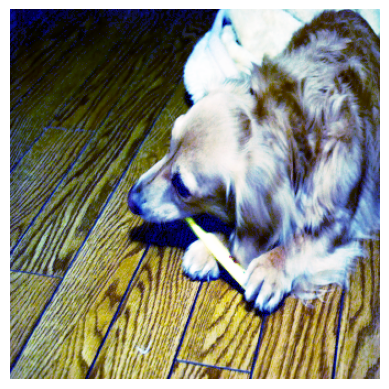

KeyboardInterrupt: 

In [6]:
#test_pr_coef = len( test_loader ) // 20
test_pr_coef = 10

transforms_inv = v2.Compose([
    v2.Normalize((-0.48145466/0.26862954, -0.4578275/0.26130258, -0.40821073/0.27577711), (1/0.26862954,1/0.26130258,1/0.27577711)),
    v2.ToPILImage()
])

# 検証
with tqdm(test_loader) as pbar:
    pbar.set_description(f'[テスト]')

    # 評価モード
    model.eval()

    test_errors = deque()
    test_bleus = deque()
    total_error = 0
    total_token_length = 0
    total_bleu = 0
    n_batch = 0
    n2 = 0
    length_max = 50
    for k, (imgs, captions, caption_lengths) in enumerate( pbar ):
        if k > 200:
            break
        # ミニバッチを設定
        imgs = imgs.to(config.device)
        captions = captions.to(config.device)
        #caption_lengths = torch.tensor( caption_lengths ).to(config.device)
        
        with torch.no_grad():
            outputs = inference(imgs, length_max )
            hypo_ids = outputs

        n = 0
        hypo_sentence = []
        ref_sentence = []
        ref_imgs = []
        for (hypo_id, caption, img ) in zip( hypo_ids, captions, imgs ):
            hypo = tokenizer.decode( [token_id for token_id in hypo_id.tolist() if token_id != 50256 ] )
            reference = tokenizer.decode( [token_id for token_id in caption.tolist() if token_id != 50256 ] )
            
            # 認識誤りを計算
            (error, substitute, delete, insert, ref_length) = levenshtein.calculate_error(hypo,reference)
            
            # 誤り文字数を累積する
            total_error += error
            # 文字の総数を累積する
            total_token_length += ref_length

            bleu = bleu_score.sentence_bleu( [reference], hypo, smoothing_function=fn  )
        
            total_bleu += bleu
            
            if n < 1 and n_batch % test_pr_coef == 0:
                hypo_sentence.append( hypo )
                ref_sentence.append( reference )
                ref_imgs.append( img )
                   
            n += 1
            n2 += 1
                
        n_batch += 1
        avg_error = total_error / total_token_length * 100
        print( "avg_erro:", avg_error )
        avg_bleu = total_bleu / n2 * 100
                
        test_errors.append(avg_error)
        test_bleus.append(avg_bleu)
                
        if len(test_errors) > config.moving_avg:
            test_errors.popleft()
            test_bleus.popleft()
        pbar.set_postfix({
            #'loss': torch.Tensor(test_losses).mean().item(),
            'WER': torch.Tensor(test_errors).mean().item(),
            'BLEU': torch.Tensor(test_bleus).mean().item()
        })                
                
                    
        for ( hypo_se, ref_se, img ) in zip( hypo_sentence, ref_sentence, ref_imgs ):
            print(f'test number = {k}, WER = {avg_error}, BLEU = {avg_bleu}')
            print( "refe:", ref_se )
            print( "hypo:", hypo_se )
            inv_img = transforms_inv( img )
            plt.imshow( inv_img )
            plt.axis('off')
            plt.show()


# 表示
test_error = np.mean( test_errors )
test_bleu = np.mean( test_bleus )
print(f'test WER: {test_error}')
print(f'test BLEU: {test_bleu}')

In [51]:
reference="A motorbike is parked on a gravel road beside a small river and green woods."
hypo="A motorcycle parked on a dirt road next to a forest.bras."

(error, substitute, delete, insert, ref_length) = levenshtein.calculate_error(hypo,reference)

print( error, substitute, delete, insert, ref_length )
print( error / ref_length * 100 )

42 23 19 0 76
55.26315789473685
